# Dataset Preprocessing

In [1]:
#################################
# Coded by Tee Yu Xiang
#################################

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_dataloaders(data_dir,batch_size = 32):
    train_dir = os.path.join(data_dir,'train')
    val_dir = os.path.join(data_dir,'test')

    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomGrayscale(p=0.1),   # faces are sometimes grayscale
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.2),     # simulate occlusion
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485,0.456,0.406],std = [0.229,0.224,0.225])
    ])

    train_dataset = datasets.ImageFolder(root = train_dir, transform = train_transforms)
    val_dataset = datasets.ImageFolder(root = val_dir, transform = val_transforms)

    target_list = torch.tensor(train_dataset.targets)
    class_count = [i for i in torch.unique(target_list, return_counts=True)[1]]
    class_weights_all = 1./torch.tensor(class_count, dtype=torch.float)
    sample_weights = class_weights_all[target_list]
    
    sampler = torch.utils.data.WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size = batch_size, num_workers = 2)

    class_name = train_dataset.classes

    return train_loader, val_loader, class_name, train_dataset

In [2]:
train_loader, val_loader, class_name, train_dataset = get_dataloaders("/kaggle/input/datasets/ananthu017/emotion-detection-fer")
image, labels = next(iter(train_loader))
print(image.shape)
print(labels.shape)
print(labels[:5])
print(class_name)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([1, 1, 2, 1, 2])
['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision
def show_image(img_tensor, title=None):
    # Convert tensor from (Channel, Height, Width) to (Height, Width, Channel) for matplotlib
    img = img_tensor.numpy().transpose((1, 2, 0))
    
    # Un-normalize the image using the same stats from your transforms
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    
    # Clip values to ensure they fall strictly between 0 and 1
    img = np.clip(img, 0, 1)
    
    # Plot the image
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

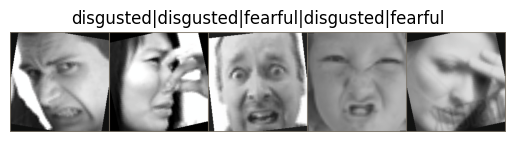

In [4]:
grid_image = torchvision.utils.make_grid(image[:5])
titles = [class_name[labels[j].item()] for j in range(5)]
show_image(grid_image,title='|' .join(titles))

# ResNet50 Setup

In [5]:
#################################
# Coded by Chan Sin Ying
#################################

import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class EngagementModel(nn.Module):
    def __init__(self, num_classes=7):
        super(EngagementModel, self).__init__()

        # Load pretrained ResNet50
        self.model = models.resnet50(weights="IMAGENET1K_V1")

        # Get input features of FC layer
        in_features = self.model.fc.in_features
        self.model.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Replace classification head
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512,num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
resnet50 = EngagementModel(num_classes=len(class_name)).to(device)

## Training Pipeline

In [6]:
def train_one_epoch(model, train_loader, loss_function, epoch, optimizer, device, log_step=300):
    model.train()

    running_loss = 0.0
    total_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):

        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        total_loss += loss.item()
        
        if (i + 1) % log_step == 0 or (i + 1) == len(train_loader):
            print(f"[Epoch {epoch+1}, Iter {i+1}] Loss: {running_loss / (i+1):.4f}")
        
    return total_loss / len(train_loader)

In [7]:
def evaluate(model, test_loader, loss_function, device):
    model.eval()

    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = loss_function(outputs, labels)

            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = total_loss / len(test_loader)
    test_acc = 100 * correct / total

    return test_loss, test_acc

In [8]:
def train_and_evaluate(model, optimizer, loss_function, train_loader, test_loader, config, device, scheduler):
    best_acc = 0.0
    start_epoch = 0

    # Resume from checkpoint if it exists
    checkpoint_path = "/kaggle/input/datasets/yuxiangtee/emotion-resnet50-checkpoint/checkpoint.pth"    
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        scheduler.load_state_dict(checkpoint['scheduler_state'])
        start_epoch = checkpoint['epoch'] + 1
        best_acc = checkpoint['best_acc']
        print(f"Resumed from epoch {start_epoch}, best acc so far: {best_acc:.2f}%")

    for epoch in range(start_epoch, config['num_epochs']):

        train_loss = train_one_epoch(
            model, train_loader, loss_function,
            epoch, optimizer, device
        )

        test_loss, test_acc = evaluate(
            model, test_loader, loss_function, device
        )

        if scheduler is not None:
            scheduler.step()

        print(f"""
        Epoch {epoch+1} Summary:
        Train Loss: {train_loss:.4f}
        Test Loss: {test_loss:.4f}
        Test Accuracy: {test_acc:.2f}%
        """)

        # Save checkpoint every epoch
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'best_acc': best_acc,
        }, "/kaggle/working/checkpoint.pth")

        # Save best model separately
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
            print(f"  ✓ New best saved: {best_acc:.2f}%")


## Control Layers to Train

In [9]:
# FREEZE / UNFREEZE LAYERS

# Freeze all layers
for param in resnet50.model.parameters():
    param.requires_grad = False

for param in resnet50.model.layer1.parameters():
    param.requires_grad = True

for param in resnet50.model.layer2.parameters():
    param.requires_grad = True
    
for param in resnet50.model.layer3.parameters():
    param.requires_grad = True
    
for param in resnet50.model.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier head
for param in resnet50.model.fc.parameters():
    param.requires_grad = True


## Loss & Optimizer

In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
weights = compute_class_weight('balanced', classes=np.unique(train_dataset.targets), y=train_dataset.targets)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

loss_function = nn.CrossEntropyLoss(label_smoothing = 0.1)

optimizer = optim.AdamW([
    {"params": resnet50.model.layer1.parameters(), "lr": 1e-6},
    {"params": resnet50.model.layer2.parameters(), "lr": 1e-5},
    {"params": resnet50.model.layer3.parameters(), "lr": 1e-5},
    {"params": resnet50.model.layer4.parameters(), "lr": 1e-4},
    {"params": resnet50.model.fc.parameters(),     "lr": 1e-3},
], weight_decay=1e-4)

In [11]:
from torch.optim.lr_scheduler import LinearLR, SequentialLR

warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
cosine = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=7)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[3])

## Train & Save the Model

In [12]:
train_and_evaluate(
    model=resnet50,
    optimizer=optimizer,
    loss_function=loss_function,
    train_loader=train_loader,
    test_loader=val_loader,
    config={"num_epochs": 33},
    device=device,
    scheduler=scheduler
)

Resumed from epoch 34, best acc so far: 69.82%


In [13]:
torch.save(resnet50.state_dict(), "/kaggle/working/emotion_resnet50.pth")

# Experimentation & Optimization (Finetune)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet50 = EngagementModel(num_classes=7).to(device)

resnet50.load_state_dict(torch.load(
    "/kaggle/working/emotion_resnet50.pth",
    map_location=device
))

<All keys matched successfully>

In [15]:
train_losses = [
    1.6778, 1.4276, 1.2785, 1.2100, 1.1433, 1.0707, 1.0181, 0.9535, 0.8986, 0.8621,
    0.9720, 0.9433, 0.8906, 0.8332, 0.7908, 0.7318, 0.7179, 0.8253, 0.8073, 0.7739,
    0.7242, 0.6857, 0.6444, 0.6344, 0.7317, 0.7263, 0.7002, 0.6637, 0.6265, 0.5991,
    0.5914, 0.6862, 0.6777, 0.6540
]
 
test_losses = [
    1.5314, 1.3803, 1.2704, 1.2223, 1.2289, 1.2428, 1.1659, 1.1565, 1.1602, 1.1483,
    1.2262, 1.1988, 1.1849, 1.2116, 1.2195, 1.2017, 1.1893, 1.2661, 1.2228, 1.2367,
    1.2349, 1.2056, 1.2079, 1.1992, 1.2741, 1.2890, 1.2541, 1.2400, 1.2238, 1.2338,
    1.2276, 1.2499, 1.2585, 1.2618
]
 
test_accs = [
    46.21, 54.58, 60.23, 61.95, 61.94, 63.12, 66.41, 67.50, 68.17, 68.40,
    65.84, 65.94, 67.16, 67.86, 67.90, 68.77, 69.02, 66.10, 67.36, 66.83,
    68.06, 69.46, 69.74, 69.75, 66.68, 66.82, 68.32, 68.96, 69.13, 69.74,
    69.82, 68.29, 68.96, 69.02
]
 
epochs = list(range(1, len(train_losses) + 1))

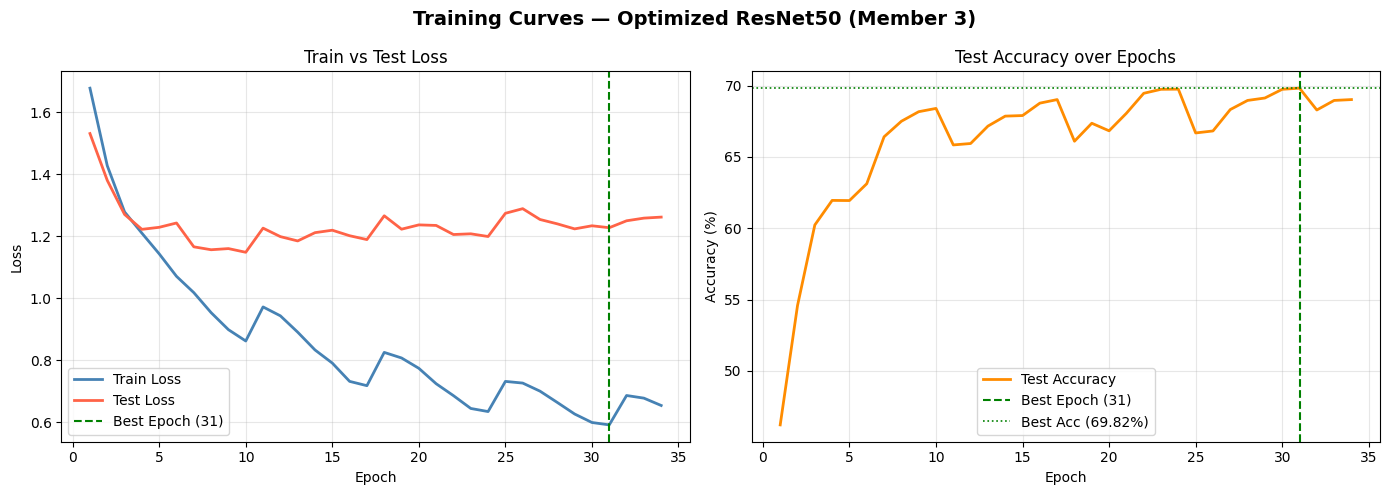

Saved to /kaggle/working/training_curves.png


In [16]:
import matplotlib.pyplot as plt
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — Optimized ResNet50 (Member 3)', fontsize=14, fontweight='bold')
 
# Loss curve
ax1.plot(epochs, train_losses, label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(epochs, test_losses, label='Test Loss', color='tomato', linewidth=2)
ax1.axvline(x=31, color='green', linestyle='--', linewidth=1.5, label='Best Epoch (31)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train vs Test Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
 
# Accuracy curve
ax2.plot(epochs, test_accs, label='Test Accuracy', color='darkorange', linewidth=2)
ax2.axvline(x=31, color='green', linestyle='--', linewidth=1.5, label='Best Epoch (31)')
ax2.axhline(y=69.82, color='green', linestyle=':', linewidth=1.2, label='Best Acc (69.82%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Test Accuracy over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /kaggle/working/training_curves.png")

In [17]:
import pandas as pd
 
ablation_data = {
    'Component': [
        'Baseline (Member 2)',
        '+ More layers unfrozen (layer1-4)',
        '+ Wider FC head + BatchNorm',
        '+ Differential LRs + Warmup + Cosine Scheduler',
        '+ Label Smoothing (0.1)',
        '+ Stronger Augmentation (ColorJitter, RandomErasing)',
        '+ WeightedRandomSampler (class balancing)',
        'Final (All components, Best Epoch 31)',
    ],
    'Test Accuracy (%)': [63.35, '-', '-', '-', '-', '-', '-', 69.82],
    'Notes': [
        'layer4 + FC only, 10 epochs, no scheduler',
        'Allows earlier feature adaptation',
        'More capacity, stable training with BN',
        'Prevents LR being too large/small per layer',
        'Reduces overconfident predictions',
        'Simulates occlusion and lighting variance',
        'Addresses class imbalance in FER2013',
        '+6.47% over baseline',
    ]
}
 
df_ablation = pd.DataFrame(ablation_data)
print("=== Ablation Study: Component Contributions ===\n")
print(df_ablation.to_string(index=False))

=== Ablation Study: Component Contributions ===

                                           Component Test Accuracy (%)                                       Notes
                                 Baseline (Member 2)             63.35   layer4 + FC only, 10 epochs, no scheduler
                   + More layers unfrozen (layer1-4)                 -           Allows earlier feature adaptation
                         + Wider FC head + BatchNorm                 -      More capacity, stable training with BN
      + Differential LRs + Warmup + Cosine Scheduler                 - Prevents LR being too large/small per layer
                             + Label Smoothing (0.1)                 -           Reduces overconfident predictions
+ Stronger Augmentation (ColorJitter, RandomErasing)                 -   Simulates occlusion and lighting variance
           + WeightedRandomSampler (class balancing)                 -        Addresses class imbalance in FER2013
               Final (All compo

# Testing & Demo

In [18]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import numpy as np
from PIL import Image
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
# Must match the architecture used during training
class EngagementModel(nn.Module):
    def __init__(self, num_classes=7):
        super(EngagementModel, self).__init__()
        self.model = models.resnet50(weights=None)
        in_features = self.model.fc.in_features
        self.model.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )
 
    def forward(self, x):
        return self.model(x)
 
CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
 
model = EngagementModel(num_classes=7).to(device)
model.load_state_dict(torch.load(
    "/kaggle/input/datasets/yuxiangtee/emotion-resnet50-checkpoint/best_model.pth",
    map_location=device
))
model.eval()
print("Best model loaded successfully.")

Best model loaded successfully.


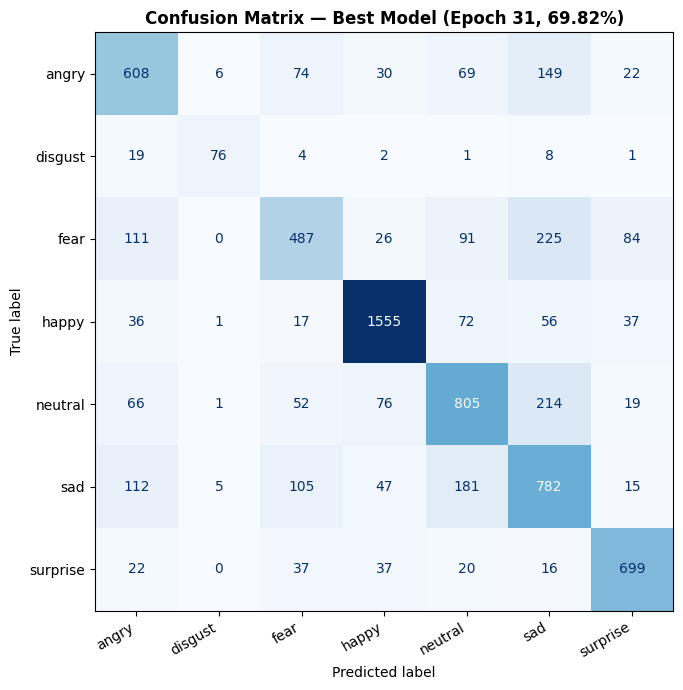

Saved to /kaggle/working/confusion_matrix.png

=== Classification Report ===

              precision    recall  f1-score   support

       angry     0.6242    0.6347    0.6294       958
     disgust     0.8539    0.6847    0.7600       111
        fear     0.6276    0.4756    0.5411      1024
       happy     0.8770    0.8766    0.8768      1774
     neutral     0.6497    0.6529    0.6513      1233
         sad     0.5393    0.6271    0.5799      1247
    surprise     0.7970    0.8412    0.8185       831

    accuracy                         0.6982      7178
   macro avg     0.7098    0.6847    0.6939      7178
weighted avg     0.7004    0.6982    0.6970      7178



In [19]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
 
all_preds = []
all_labels = []
 
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs,1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
 
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Best Model (Epoch 31, 69.82%)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /kaggle/working/confusion_matrix.png")
 
# F1 Score + Per-class Report
print("\n=== Classification Report ===\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

In [20]:
def predict_emotion(image_input, model, device, class_names=CLASS_NAMES):

    engagement_weights = {
        "happy": 1.0,
        "surprise": 0.9,
        "neutral": 0.5,
        "sad": 0.2,
        "fear": 0.2,
        "angry": 0.1,
        "disgust": 0.0
    }

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    if isinstance(image_input, str):
        img = Image.open(image_input).convert('RGB')
    elif isinstance(image_input, np.ndarray):
        img = Image.fromarray(image_input[:, :, ::-1])
    else:
        img = image_input.convert('RGB')

    tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()

    predicted_label = class_names[pred_idx]
    confidence = probs[pred_idx].item() * 100

    # ✅ Engagement score
    engagement_score = 0
    for i, emotion in enumerate(class_names):
        engagement_score += probs[i].item() * engagement_weights[emotion]

    all_probs = {
        class_names[i]: round(probs[i].item() * 100, 2)
        for i in range(len(class_names))
    }

    return predicted_label, confidence, all_probs, engagement_score

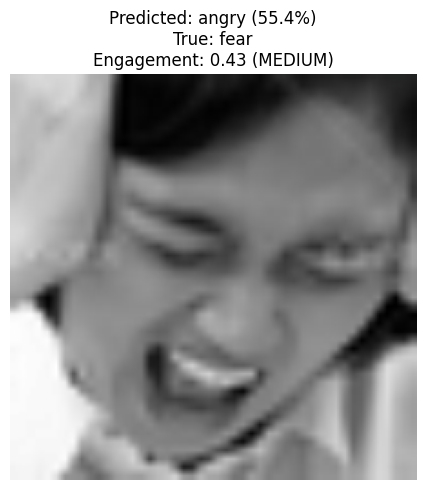


Predicted: angry (55.4%)
True Label: fear
Engagement Score: 0.43 (MEDIUM)

All probabilities:
  angry     : 55.44%
  happy     : 34.54%
  fear      : 3.12%
  sad       : 2.17%
  surprise  : 1.82%
  disgust   : 1.74%
  neutral   : 1.17%


In [43]:
# Quick Test with Engagement
import random
import torch
import matplotlib.pyplot as plt

# 1. Pick a random index
random_idx = random.randint(0, len(val_loader.dataset) - 1)

# 2. Extract image and label
img_tensor, true_label_idx = val_loader.dataset[random_idx]

# De-normalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_display = torch.clamp(img_tensor * std + mean, 0, 1)

# 🔥 Convert tensor → PIL image (needed for predict_emotion)
from torchvision.transforms.functional import to_pil_image
img_pil = to_pil_image(img_display)

# 🔥 Use your function (with engagement)
emotion, confidence, all_probs, engagement = predict_emotion(
    img_pil, model, device, CLASS_NAMES
)

# Get true label
if isinstance(true_label_idx, torch.Tensor):
    true_label_idx = true_label_idx.item()
true_label = CLASS_NAMES[true_label_idx]

# 🔹 Determine engagement level
if engagement > 0.7:
    level = "HIGH"
elif engagement > 0.4:
    level = "MEDIUM"
else:
    level = "LOW"

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(img_display.permute(1, 2, 0))
plt.title(
    f"Predicted: {emotion} ({confidence:.1f}%)\n"
    f"True: {true_label}\n"
    f"Engagement: {engagement:.2f} ({level})",
    fontsize=12
)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print results
print(f"\nPredicted: {emotion} ({confidence:.1f}%)")
print(f"True Label: {true_label}")
print(f"Engagement Score: {engagement:.2f} ({level})")

print(f"\nAll probabilities:")
for e, prob in sorted(all_probs.items(), key=lambda x: -x[1]):
    print(f"  {e:<10}: {prob:.2f}%")